In [11]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
sys.path.append(r"C:\Users\super\DAG")
sys.path.append(r"C:\Users\super\DAG\coordinate_descent")  # for cd_greedy_A internal imports
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

from MEC import is_in_markov_equiv_class
from SCM_data import generate_scm_from_BN
from numpy.linalg import inv
from scipy.linalg import sqrtm

# cd_A_noepoch: T-step random coordinate descent
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0, f as f_A
# cd_A_greedy_noepoch: T-step greedy coordinate descent
from coordinate_descent.cd_greedy_A import dag_greedy_A

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\super\DAG\experiments\notebooks\test


In [12]:
# Experiment: d=4, A->C, A->D, B->C, B->D (same as test_cd_ell_visualize)
experiment = {
    "name": "d=4, A→C, A→D, B→C, B→D",
    "B_true": np.array([
        [0, 0, 2, 3],
        [0, 0, 3, 4],
        [0, 0, 0, 0],
        [0, 0, 0, 0]
    ]),
    "N": np.array([2, 4, 3, 5]),
}

print(f"=== Experiment: {experiment['name']} ===")
print(f"B_true:\n{experiment['B_true']}")
print(f"N: {experiment['N']}")

=== Experiment: d=4, A→C, A→D, B→C, B→D ===
B_true:
[[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
N: [2 4 3 5]


In [13]:
# Generate synthetic data
n_samples = 5000
seed = 41

B_true = experiment["B_true"]
N = experiment["N"]
d = B_true.shape[0]

data, G_true_gen, _, _ = generate_scm_from_BN(
    B_true.T,
    n_samples=n_samples,
    N=N,
    seed=seed
)
n, d = data.shape

# Sample covariance
S = data.T @ data / n

# True A and true score
Omega_true = np.diag(N)
A_true = (np.eye(d) - B_true) @ inv(sqrtm(Omega_true))
score_true_A = f_A(A_true, S)

print(f"B_true =\n{B_true}")
print(f"A_true =\n{A_true}")
print(f"Generated {n_samples} samples")
print(f"Score_true (f_A with A_true): {score_true_A:.6f}")

B_true =
[[0 0 2 3]
 [0 0 3 4]
 [0 0 0 0]
 [0 0 0 0]]
A_true =
[[ 0.70710677  0.         -1.15470052 -1.34164077]
 [ 0.          0.5        -1.73205078 -1.78885436]
 [ 0.          0.          0.57735026  0.        ]
 [ 0.          0.          0.          0.44721359]]
Generated 5000 samples
Score_true (f_A with A_true): 8.795137


In [14]:
# Algorithm parameters
T = 3000          # number of steps
lambda_l0 = 0.0   # no sparsity penalty (focus on convergence)
threshold = 0.05

print(f"Steps T = {T}")
print(f"lambda_l0 = {lambda_l0}")

Steps T = 3000
lambda_l0 = 0.0


In [15]:
# cd_A_noepoch: random coordinate descent (T steps)
print("Running cd_A_noepoch ...")
A_rand, G_rand, score_rand, history_rand = dag_coordinate_descent_l0(
    S,
    T=T,
    seed=seed,
    threshold=threshold,
    lambda_l0=lambda_l0,
    return_history=True,
)
print(f"Final score: {score_rand:.6f}  (true: {score_true_A:.6f})")
print(f"Is in MEC: {is_in_markov_equiv_class(G_rand, B_true)}")

Running cd_A_noepoch ...
Final score: 8.793270  (true: 8.795137)
Is in MEC: True


In [16]:
# cd_A_greedy_noepoch: greedy coordinate descent (T steps)
print("Running cd_A_greedy_noepoch ...")
A_greedy, G_greedy, score_greedy, history_greedy = dag_greedy_A(
    S,
    T=T,
    seed=seed,
    threshold=threshold,
    lambda_l0=lambda_l0,
    return_history=True,
)
print(f"Final score: {score_greedy:.6f}  (true: {score_true_A:.6f})")
print(f"Is in MEC: {is_in_markov_equiv_class(G_greedy, B_true)}")

Running cd_A_greedy_noepoch ...
Final score: 62.965002  (true: 8.795137)
Is in MEC: False


In [17]:
is_mec_rand   = is_in_markov_equiv_class(G_rand, B_true)
is_mec_greedy = is_in_markov_equiv_class(G_greedy, B_true)

print("=" * 55)
print("SUMMARY")
print("=" * 55)
print(f"Score_true (f_A): {score_true_A:.6f}")
print()
print(f"{'Algorithm':<25} {'Final Score':<15} {'Gap':<12} {'In MEC'}")
print("-" * 55)
for name, sc, mec in [
    ("cd_A_noepoch",        score_rand,   is_mec_rand),
    ("cd_A_greedy_noepoch", score_greedy, is_mec_greedy),
]:
    gap = sc - score_true_A
    print(f"{name:<25} {sc:<15.6f} {gap:<12.6f} {str(mec)}")

SUMMARY
Score_true (f_A): 8.795137

Algorithm                 Final Score     Gap          In MEC
-------------------------------------------------------
cd_A_noepoch              8.793270        -0.001867    True
cd_A_greedy_noepoch       62.965002       54.169866    False


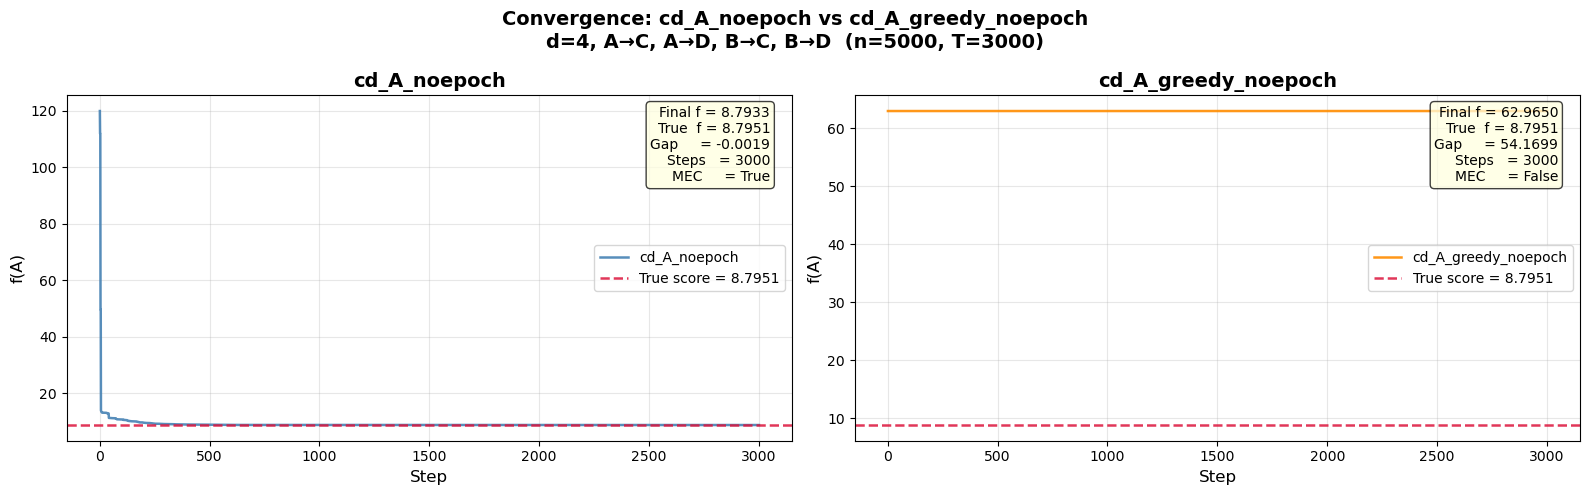

In [18]:
# Visualization 1: separate panels
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

configs = [
    (axes[0], history_rand,   score_rand,   is_mec_rand,   "cd_A_noepoch",        "steelblue"),
    (axes[1], history_greedy, score_greedy, is_mec_greedy, "cd_A_greedy_noepoch", "darkorange"),
]

for ax, history, score_final, is_mec, title, color in configs:
    steps = np.arange(1, len(history) + 1)
    ax.plot(steps, history, linewidth=1.8, color=color, label=title, alpha=0.9)
    ax.axhline(y=score_true_A, color="crimson", linestyle="--", linewidth=1.8,
               label=f"True score = {score_true_A:.4f}", alpha=0.85)
    ax.set_xlabel("Step", fontsize=12)
    ax.set_ylabel("f(A)", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    gap = score_final - score_true_A
    info = (
        f"Final f = {score_final:.4f}\n"
        f"True  f = {score_true_A:.4f}\n"
        f"Gap     = {gap:.4f}\n"
        f"Steps   = {len(history)}\n"
        f"MEC     = {is_mec}"
    )
    ax.text(0.97, 0.97, info, transform=ax.transAxes, fontsize=10,
            verticalalignment="top", horizontalalignment="right",
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.75))

plt.suptitle(
    f"Convergence: cd_A_noepoch vs cd_A_greedy_noepoch\n"
    f"{experiment['name']}  (n={n_samples}, T={T})",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

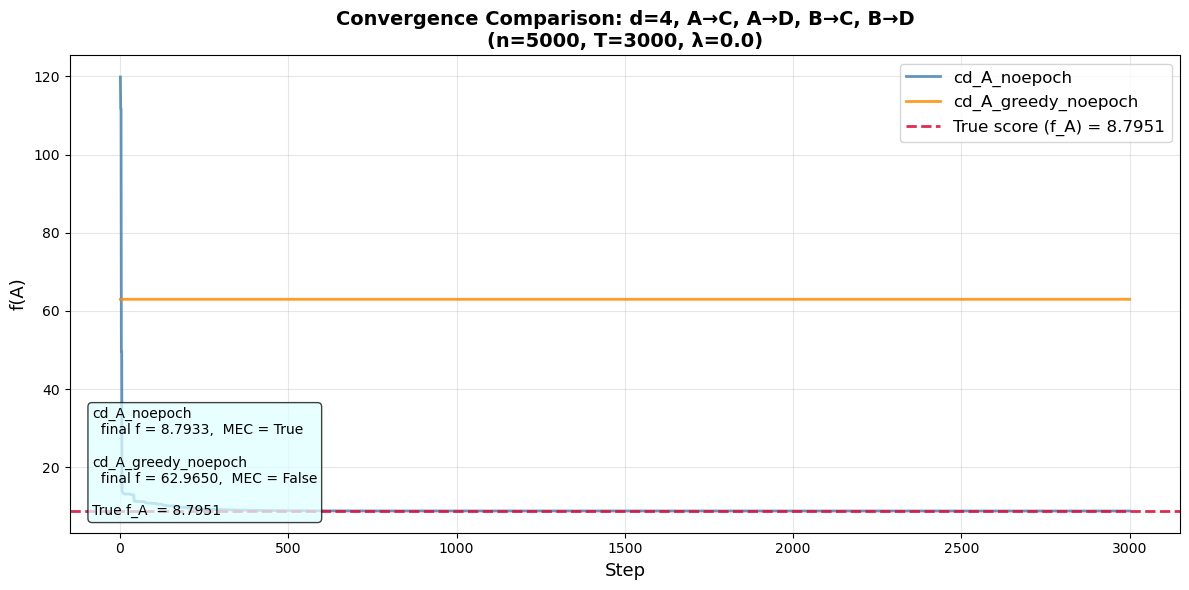

In [19]:
# Visualization 2: combined panel
fig, ax = plt.subplots(figsize=(12, 6))

steps_rand   = np.arange(1, len(history_rand)   + 1)
steps_greedy = np.arange(1, len(history_greedy) + 1)

ax.plot(steps_rand,   history_rand,   linewidth=2, color="steelblue",
        label="cd_A_noepoch", alpha=0.85)
ax.plot(steps_greedy, history_greedy, linewidth=2, color="darkorange",
        label="cd_A_greedy_noepoch", alpha=0.85)
ax.axhline(y=score_true_A, color="crimson", linestyle="--", linewidth=2,
           label=f"True score (f_A) = {score_true_A:.4f}", alpha=0.9)

ax.set_xlabel("Step", fontsize=13)
ax.set_ylabel("f(A)", fontsize=13)
ax.set_title(
    f"Convergence Comparison: {experiment['name']}\n(n={n_samples}, T={T}, λ={lambda_l0})",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

info = (
    f"cd_A_noepoch\n"
    f"  final f = {score_rand:.4f},  MEC = {is_mec_rand}\n\n"
    f"cd_A_greedy_noepoch\n"
    f"  final f = {score_greedy:.4f},  MEC = {is_mec_greedy}\n\n"
    f"True f_A  = {score_true_A:.4f}"
)
ax.text(0.02, 0.03, info, transform=ax.transAxes, fontsize=10,
        verticalalignment="bottom", horizontalalignment="left",
        bbox=dict(boxstyle="round", facecolor="lightcyan", alpha=0.75))

plt.tight_layout()
plt.show()

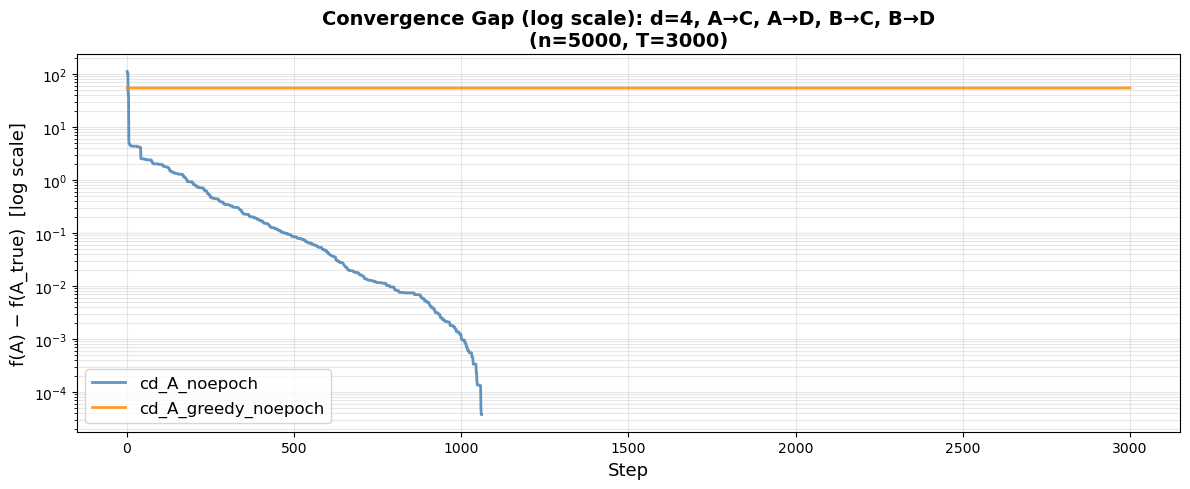

: 

In [ ]:
# Visualization 3: log-scale gap (convergence rate)
fig, ax = plt.subplots(figsize=(12, 5))

gap_rand   = np.array(history_rand)   - score_true_A
gap_greedy = np.array(history_greedy) - score_true_A

mask_rand   = gap_rand   > 1e-8
mask_greedy = gap_greedy > 1e-8

if mask_rand.any():
    ax.semilogy(steps_rand[mask_rand], gap_rand[mask_rand],
                linewidth=2, color="steelblue", label="cd_A_noepoch", alpha=0.85)
if mask_greedy.any():
    ax.semilogy(steps_greedy[mask_greedy], gap_greedy[mask_greedy],
                linewidth=2, color="darkorange", label="cd_A_greedy_noepoch", alpha=0.85)

ax.set_xlabel("Step", fontsize=13)
ax.set_ylabel("f(A) − f(A_true)  [log scale]", fontsize=13)
ax.set_title(
    f"Convergence Gap (log scale): {experiment['name']}\n(n={n_samples}, T={T})",
    fontsize=14, fontweight="bold"
)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3, which="both")

plt.tight_layout()
plt.show()